# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Grimaldi Damián Daniel
- Alumno 2 : Grando Sofía

## Dataset
- Ubicación: https://drive.google.com/drive/folders/1uz4Rwhidre9K-GnfONCSI7t7-kCRp2XB?usp=sharing

- Fecha de creación: Mayo 2026.

- Total de clases (personas): 14.

- Total de imágenes: 491.

- Formato de archivos: .jpg, .jpeg, .png, etc.

### 1. Fuente de las imagenes: 
- **Privada:** imágenes provenientes de la galería de los integrantes del grupo (familia y amigos).

- **Pública:** imágenes de figuras públicas obtenidas de internet para aumentar la diversidad de rasgos. 

### 2. Balance de clases:
|indice|nombre|tipo|cant. de fotos|
|------|------|------|------|
|0|Amanda|amigo|37|
|1|Angel|amigo|30|
|2|Cesar|familia|35|
|3|Damian|amigo|33|
|4|Deborah|amigo|34|
|5|Facundo|amigo|35|
|6|Harry Styles|famoso|35|
|7|Louis Tomlinson|famoso|36|
|8|Luisina|amigo|36|
|9|Marta|familia|39|
|10|Nicolas|amigo|35|
|11|Sofia|amigo|35|
|12|Sol|amigo|35|
|13|Taylor Swift|famoso|36|

El dataset es balanceado, con un promedio de 35 imagenes por clase. La diferencia entre la clase con mayor cantidad de imagenes (Marta, 39) y la menor (Ángel, 30) es baja.

### 3. Variaciones:
Para asegurarnos que el modelo reconozca a personas en situaciones del mundo real se seleccionaron imagenes con diferentes variaciones de iluminacion, poses, expresiones, accesorios y looks (cambios de cabello y maquillaje). 

### 4. Reglas de filtrado y calidad:
No se aceptaron todas las imagenes extraidas de la galeria. Se aplicó un filtrado manual para eliminar todas aquellas con baja resolucion o nitidez y se recortaron algunas para asegurar que solo exista un rostro visible. 
Para aquellas clases con menor volumen de datos, se aplicaron técnicas de *Data Augmentation*, como rotaciones leves, espejado horizontal y ajustes de brillo y contraste. Esto permitió expandir el dataset y lograr el balance.

TODO utiliza esta notebook para documentar, entrenar y probar el modelo.

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

In [ ]:
def carga_dataset(dataset_path: str) -> dict:
    """
    Carga imágenes del dataset y las convierte
    todas a formato RGB consistente.
    """

    data = {}

    for persona in os.listdir(dataset_path):

        carpeta = os.path.join(dataset_path, persona)

        if not os.path.isdir(carpeta):
            continue

        data[persona] = []

        for archivo in os.listdir(carpeta):

            img_path = os.path.join(carpeta, archivo)

            try:
                img = Image.open(img_path).convert("RGB")

                data[persona].append(img)

            except Exception as e:
                print(f"Error cargando {img_path}: {e}")
                continue

    return data

Cargamos las imagenes con el mismo tipo de formato, que en este caso, utilizamos RGB, para que de este modo, MTCNN, tiene que tener un formato consistente para realizar una mejor detección.

In [19]:
personas_dataset = carga_dataset("data")

In [16]:
def detection_face(img) -> list[tuple[int,int,int,int]] | None:
    try:
        from facenet_pytorch import MTCNN

        faces = []

        detector = MTCNN(image_size=112, margin=0, keep_all=True)
        boxes, probs = detector.detect(img)
        if boxes is None:
            return None

        print(f"Detected {len(boxes)} faces")
        for i, (box, prob) in enumerate(zip(boxes, probs)):
            print(f"  Face {i+1}: box={box.astype(int)}, confidence={prob:.3f}")
            if prob < 0.90:
                print(f"    Skipping face {i+1} due to low confidence")
                continue
            x1, y1, x2, y2 = box.astype(int)
            face = (x1, y1, x2, y2)
            faces.append(face)
        return faces

    except ImportError:
        # Fallback: just resize without alignment (for demo)
        print("No MTCNN")
        return [img]
    except Exception as e:
        print(f"Error: {e}")
        return [img]

Utilizamos el modelo MTCNN, ya que a la hora de realizar la alineación facial, es más facil realizarlo. Útilizamos un umbral de 0,9 para determinar que realmente sea una cara, ya que puede darnos falsos positivos, y queremos que realmente sean rostros.

In [8]:
rostro = detection_face(personas_dataset['Damian'][1])

Detected 1 faces
  Face 1: box=[ 293  660  759 1240], confidence=1.000


Detected 1 faces
  Face 1: box=[202 140 419 410], confidence=1.000


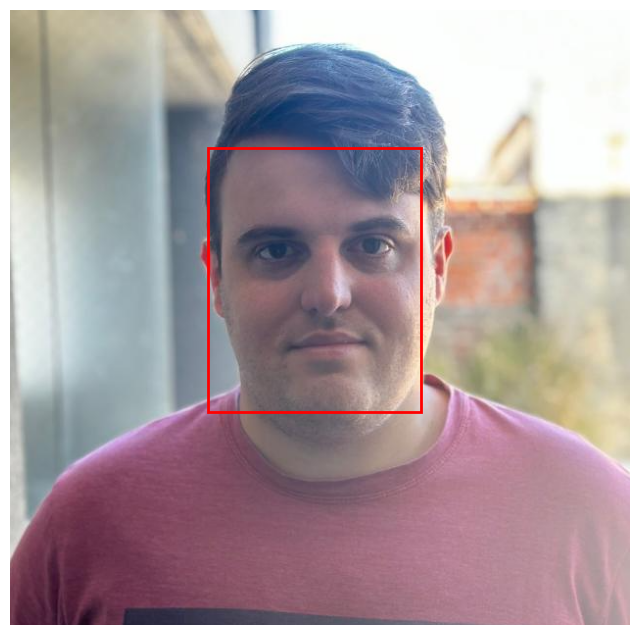

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img = personas_dataset['Damian'][0]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()

Detected 1 faces
  Face 1: box=[ 293  660  759 1240], confidence=1.000


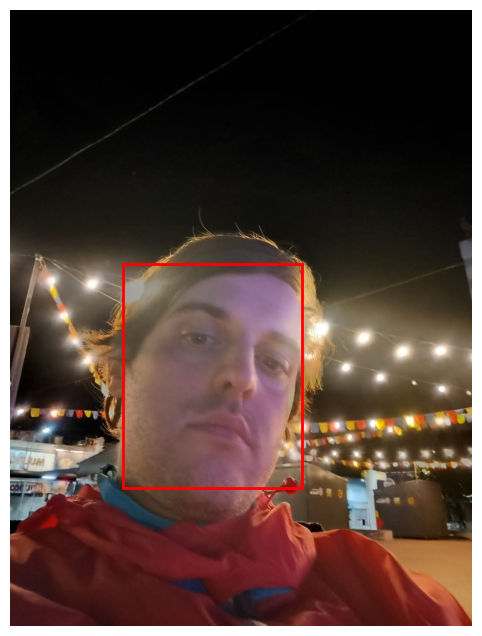

In [ ]:
img = personas_dataset['Damian'][1]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()

Detected 2 faces
  Face 1: box=[ 298  535  713 1017], confidence=1.000
  Face 2: box=[ 331  979  419 1071], confidence=0.741
    Skipping face 2 due to low confidence


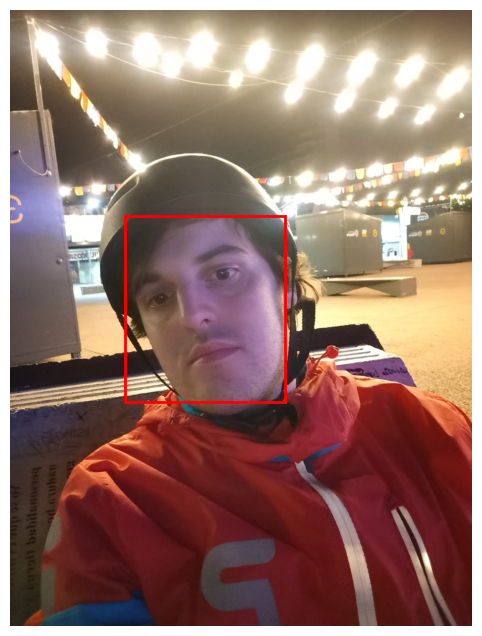

In [ ]:
img = personas_dataset['Damian'][2]

rostro = detection_face(img)

fig, ax = plt.subplots(figsize=(8,8))

# Mostrar imagen
ax.imshow(img)

# Dibujar bounding boxes
if rostro is not None:
    for (x1, y1, x2, y2) in rostro:

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

plt.axis("off")
plt.show()